# Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# Preprocessing: Weather 

## Preprocessing Weather: Load in Data

In [2]:
# Read KNMI weather file (.txt can still be comma-delimited and read with read_csv)
weather = pd.read_csv(
    "Weather 2019-2025/homogenoues weather data.txt",
    sep=",",
    skiprows=51,
    header=0,
    low_memory=False
 )

# Parse date column once so later filtering works reliably
weather["YYYYMMDD"] = pd.to_datetime(weather["YYYYMMDD"], format="%Y%m%d", errors="coerce")

# Keep only rows from 2019-01-01 through 2025-12-31 (inclusive)
start_date = pd.Timestamp("2019-01-01")
end_date = pd.Timestamp("2025-12-31")
weather = weather[(weather["YYYYMMDD"] >= start_date) & (weather["YYYYMMDD"] <= end_date)].copy()

In [3]:
# Normalize KNMI headers, so that mapping keys match
weather.columns = weather.columns.str.strip().str.lstrip("#").str.strip()

# Map original column names to more descriptive labels
column_map = {
    'STN': 'Station',
    'YYYYMMDD': 'Date',
    'DDVEC': 'Wind direction vector mean',  # degrees: 0=N, 90=E, 180=S, 270=W
    'FHVEC': 'Windspeed vector mean',
    'FG': 'Daily mean windspeed',
    'FHX': 'Max hourly mean windspeed',
    'FHXH': 'Hour of max hourly mean windspeed',
    'FHN': 'Min hourly mean windspeed',
    'FHNH': 'Hour of min hourly mean windspeed',
    'FXX': 'Max wind gust',
    'FXXH': 'Hour of max wind gust',
    'TG': 'Daily mean temperature',  # 0.1 degrees Celsius
    'TN': 'Min temperature',  # 0.1 degrees Celsius
    'TNH': 'Hour TN measured',
    'TX': 'Max temperature',  # 0.1 degrees Celsius
    'TXH': 'Hour TX measured',
    'T10N': 'Min temperature 10cm above surface',  # 0.1 degrees Celsius
    'T10NH': '6-hour period T10N measured',
    'SQ': 'Sunshine duration',  # 0.1 hour
    'SP': 'Percent max potential sunshine duration',
    'Q': 'Global radiation',  # J/cm2
    'DR': 'Precipitation duration',  # 0.1 hour
    'RH': 'Daily precipitation amount',  # 0.1 mm
    'RHX': 'Max hourly precipitation amount',  # 0.1 mm
    'RHXH': 'Hour RHX measured',
    'PG': 'Daily mean sea level pressure',  # 0.1 hPa
    'PX': 'Max hourly sea level pressure',  # 0.1 hPa
    'PXH': 'Hour PX measured',
    'PN': 'Min hourly sea level pressure',  # 0.1 hPa
    'PNH': 'Hour PN measured',
    'VVN': 'Min visibility',  # 0.1 km
    'VVNH': 'Hour VVN measured',
    'VVX': 'Max visibility',  # 0.1 km
    'VVXH': 'Hour VVX measured',
    'NG': 'Mean daily cloud cover',  # octas
    'UG': 'Daily mean relative humidity',  # percent
    'UX': 'Max relative humidity',  # percent
    'UXH': 'Hour UX measured',
    'UN': 'Min relative humidity',  # percent
    'UNH': 'Hour UN measured',
    'EV24': 'Potential evapotranspiration (Makkink)'  # 0.1 mm
}

weather = weather.rename(columns=column_map)

# Convert all columns except Date to numeric (spaces become NaN)
num_cols = [c for c in weather.columns if c != 'Date']
weather[num_cols] = weather[num_cols].apply(pd.to_numeric, errors='coerce')

# # Resolve cloud-cover column name robustly
# if 'Mean daily cloud cover' in weather.columns:
#     cloud_col = 'Mean daily cloud cover'
# elif 'NG' in weather.columns:
#     cloud_col = 'NG'
# else:
#     candidates = [c for c in weather.columns if 'cloud' in c.lower()]
#     cloud_col = candidates[0] if candidates else None

## Preprocessing Weather: Analyzing the Data

In [4]:
# Display basic information about the DataFrame: 
# number of rows, columns, data types, and non-null counts

weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 2557 entries, 43099 to 45655
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Station                                  2557 non-null   int64         
 1   Date                                     2557 non-null   datetime64[us]
 2   Wind direction vector mean               2557 non-null   int64         
 3   Windspeed vector mean                    2557 non-null   int64         
 4   Daily mean windspeed                     2557 non-null   int64         
 5   Max hourly mean windspeed                2557 non-null   int64         
 6   Hour of max hourly mean windspeed        2557 non-null   int64         
 7   Min hourly mean windspeed                2557 non-null   int64         
 8   Hour of min hourly mean windspeed        2557 non-null   int64         
 9   Max wind gust                            2557 n

In [5]:
weather.describe()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
count,2557.0,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2554.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2022-07-02 00:00:00,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,9.897927,78.020727,12.098944,6.060689,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,1.000000,15.000000,1.000000,0.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2020-10-01 00:00:00,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,3.000000,75.000000,10.000000,5.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2022-07-02 00:00:00,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,6.000000,81.000000,13.000000,7.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2024-04-01 00:00:00,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,19.000000,83.000000,16.000000,8.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2025-12-31 00:00:00,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,24.000000,83.000000,24.000000,8.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000
std,0.0,NaN,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,8.519387,7.072227,5.741769,2.163471,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101


## Preprocessing Weather: Dealing with Missing Values

In [6]:
total = weather.isnull().sum().sort_values(ascending=False)
percent = (weather.isnull().sum()/weather.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
Mean daily cloud cover,3,0.001173
Date,0,0.000000
Wind direction vector mean,0,0.000000
Windspeed vector mean,0,0.000000
Daily mean windspeed,0,0.000000
Max hourly mean windspeed,0,0.000000
Hour of max hourly mean windspeed,0,0.000000
Min hourly mean windspeed,0,0.000000
Station,0,0.000000
Hour of min hourly mean windspeed,0,0.000000


In [7]:
# Display rows with missing values
weather_null = weather[weather.isnull().any(axis=1)]
weather_null

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
45546,260,2025-09-13,189,39,40,60,10,20,15,110,...,15,83,1,NaN,85,95,24,59,12,15
45547,260,2025-09-14,191,32,37,50,12,20,4,100,...,5,83,16,NaN,82,98,4,52,14,24
45548,260,2025-09-15,226,78,79,100,10,40,1,210,...,11,73,14,NaN,73,95,1,52,14,24


In [8]:
# Check for duplicates
weather.duplicated().sum()

np.int64(0)

## Preprocessing Weather: Univariate & Bivariate Analysis

### Preprocessing Weather: Univariate

In [9]:
weather.describe()

,Station,Date,Wind direction vector mean,Windspeed vector mean,Daily mean windspeed,Max hourly mean windspeed,Hour of max hourly mean windspeed,Min hourly mean windspeed,Hour of min hourly mean windspeed,Max wind gust,...,Hour VVN measured,Max visibility,Hour VVX measured,Mean daily cloud cover,Daily mean relative humidity,Max relative humidity,Hour UX measured,Min relative humidity,Hour UN measured,Potential evapotranspiration (Makkink)
count,2557.0,2557,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,...,2557.000000,2557.000000,2557.000000,2554.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,260.0,2022-07-02 00:00:00,190.808369,29.271412,33.369183,51.286664,10.910442,16.104810,8.427063,102.655456,...,9.897927,78.020727,12.098944,6.060689,79.021118,94.676965,9.556903,61.203363,13.448573,17.732499
min,260.0,2019-01-01 00:00:00,1.000000,0.000000,7.000000,20.000000,1.000000,0.000000,1.000000,30.000000,...,1.000000,15.000000,1.000000,0.000000,37.000000,52.000000,1.000000,16.000000,1.000000,0.000000
25%,260.0,2020-10-01 00:00:00,131.000000,18.000000,23.000000,40.000000,8.000000,10.000000,1.000000,80.000000,...,3.000000,75.000000,10.000000,5.000000,73.000000,93.000000,2.000000,49.000000,12.000000,5.000000
50%,260.0,2022-07-02 00:00:00,206.000000,27.000000,31.000000,50.000000,11.000000,10.000000,4.000000,100.000000,...,6.000000,81.000000,13.000000,7.000000,80.000000,97.000000,5.000000,61.000000,14.000000,14.000000
75%,260.0,2024-04-01 00:00:00,250.000000,38.000000,41.000000,60.000000,14.000000,20.000000,18.000000,120.000000,...,19.000000,83.000000,16.000000,8.000000,87.000000,98.000000,20.000000,74.000000,15.000000,28.000000
max,260.0,2025-12-31 00:00:00,360.000000,94.000000,98.000000,150.000000,24.000000,70.000000,24.000000,310.000000,...,24.000000,83.000000,24.000000,8.000000,100.000000,100.000000,24.000000,98.000000,24.000000,59.000000
std,0.0,NaN,90.926323,14.995639,13.845270,18.055588,5.397954,11.798449,8.547612,37.214587,...,8.519387,7.072227,5.741769,2.163471,10.765404,5.835016,8.899565,16.182888,4.024110,14.754101


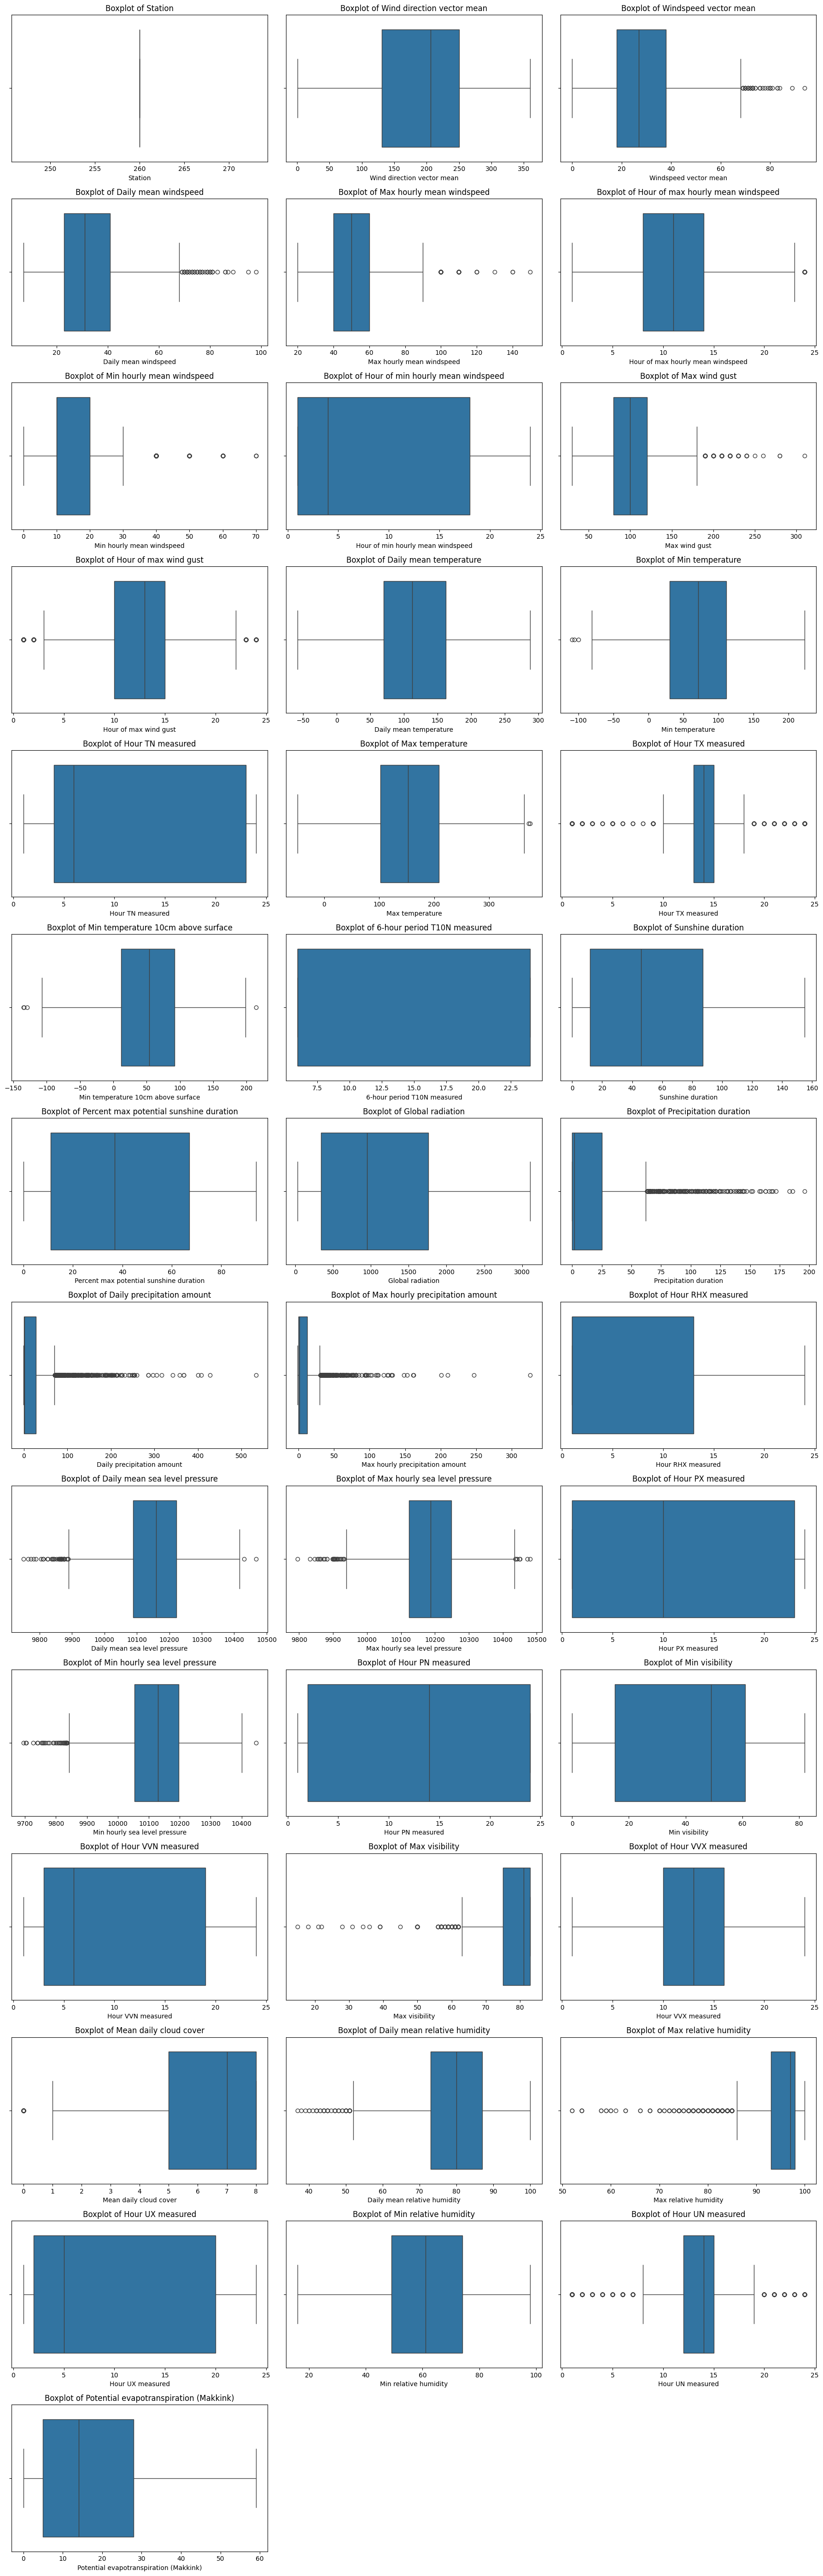

In [10]:
#boxplot: for outliers and data spread
num_cols = weather.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=weather[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

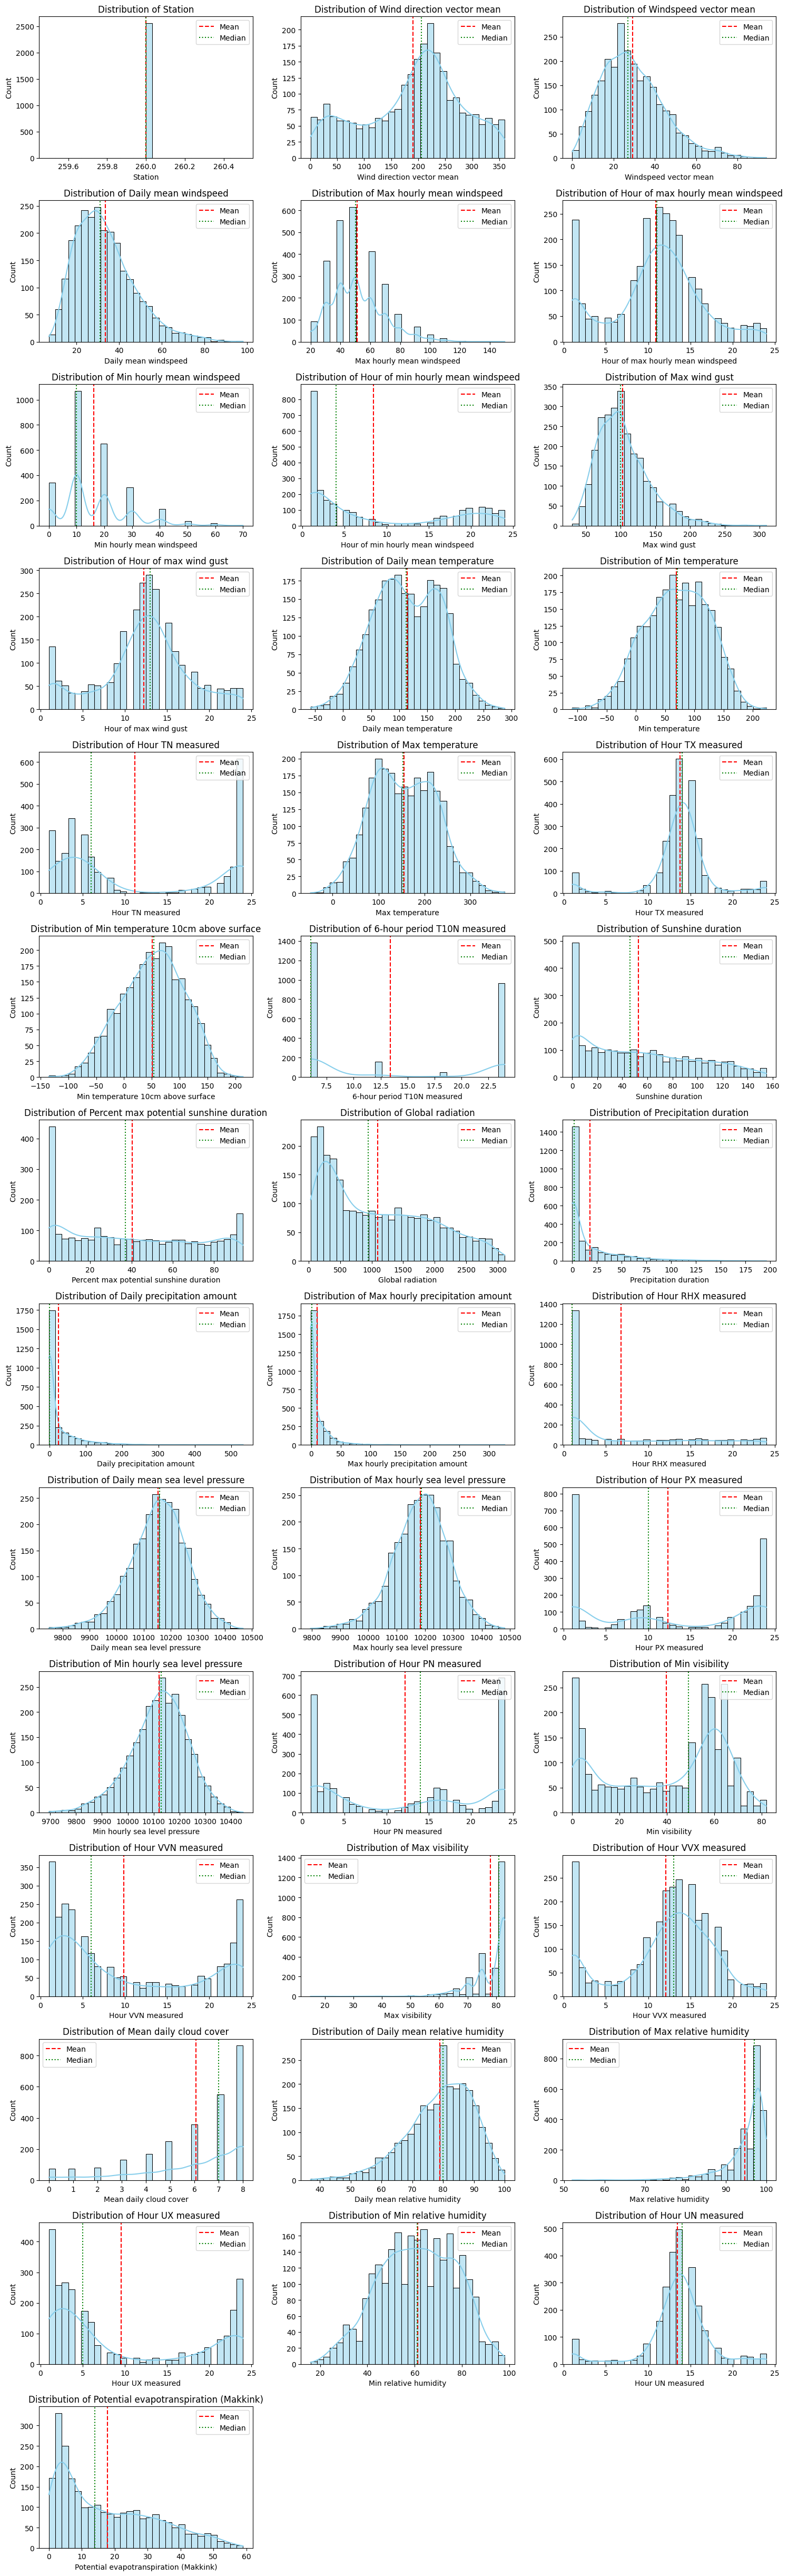

In [11]:
#histogram: for distribution and central tendency (mean, median)
n = len(num_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = weather[col].dropna()
    sns.histplot(data, bins=30, kde=True, ax=ax, color="skyblue")
    ax.axvline(data.mean(), color="red", linestyle="--", label="Mean")
    ax.axvline(data.median(), color="green", linestyle=":", label="Median")
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Preprocessing Weather: Bivariate

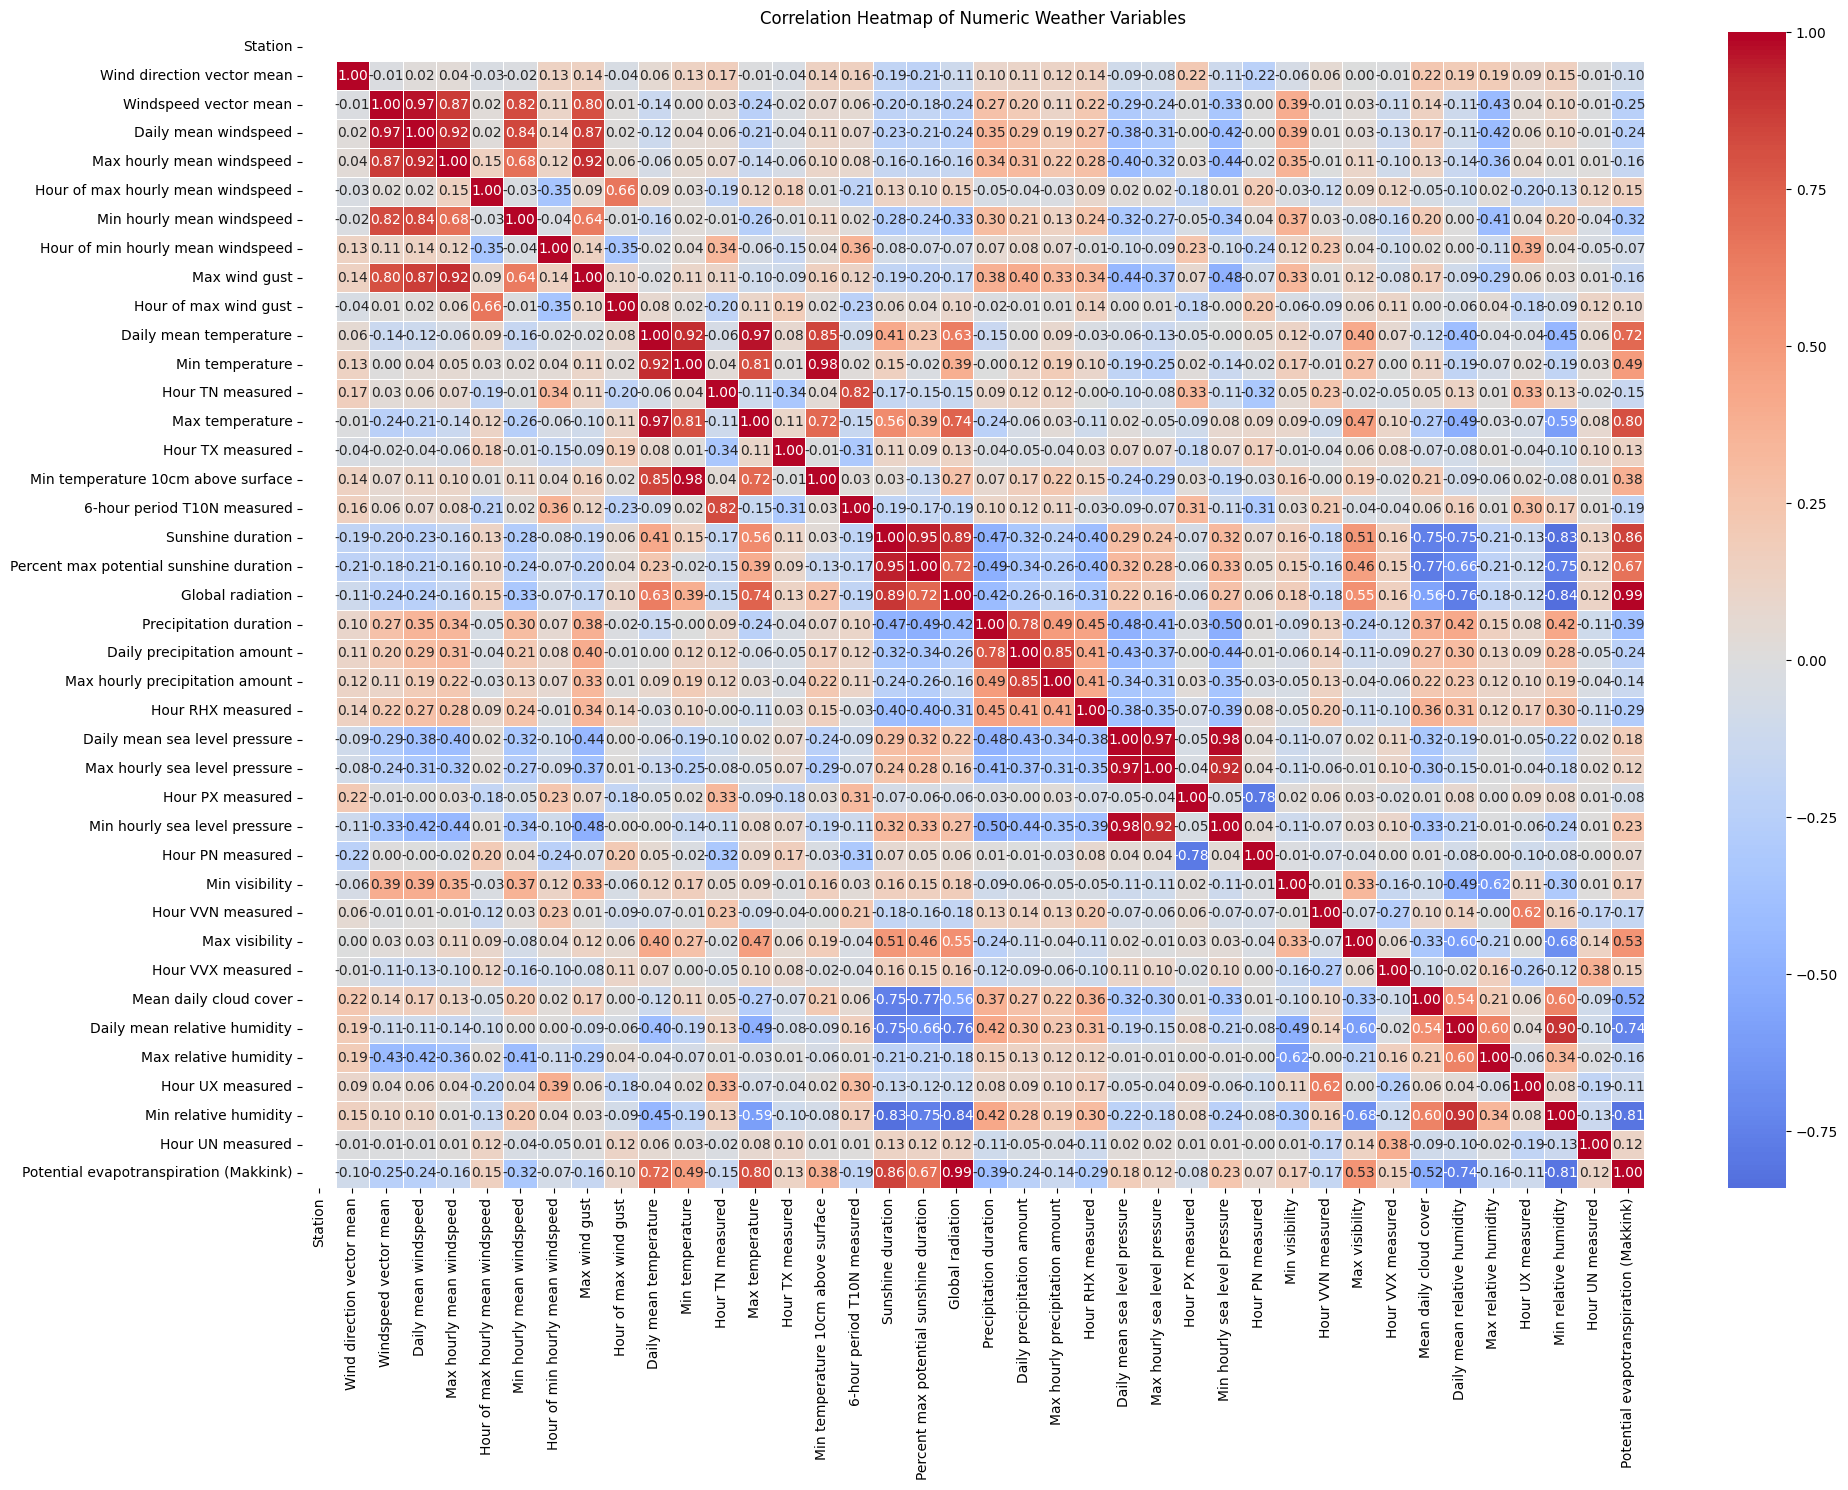

In [12]:
#heatmap: for correlation between numeric variables
corr = weather[num_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Weather Variables")
plt.tight_layout()
plt.show()

In [13]:
#check the top 10 most correlated pairs of numeric variables
corr_abs = weather[num_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

top_pairs = upper.stack().sort_values(ascending=False).head(10)
print(top_pairs)

Global radiation               Potential evapotranspiration (Makkink)     0.986972
Min temperature                Min temperature 10cm above surface         0.980163
Daily mean sea level pressure  Min hourly sea level pressure              0.978490
                               Max hourly sea level pressure              0.974933
Daily mean temperature         Max temperature                            0.966511
Windspeed vector mean          Daily mean windspeed                       0.965609
Sunshine duration              Percent max potential sunshine duration    0.948298
Daily mean windspeed           Max hourly mean windspeed                  0.921756
Max hourly sea level pressure  Min hourly sea level pressure              0.919462
Daily mean temperature         Min temperature                            0.918034
dtype: float64


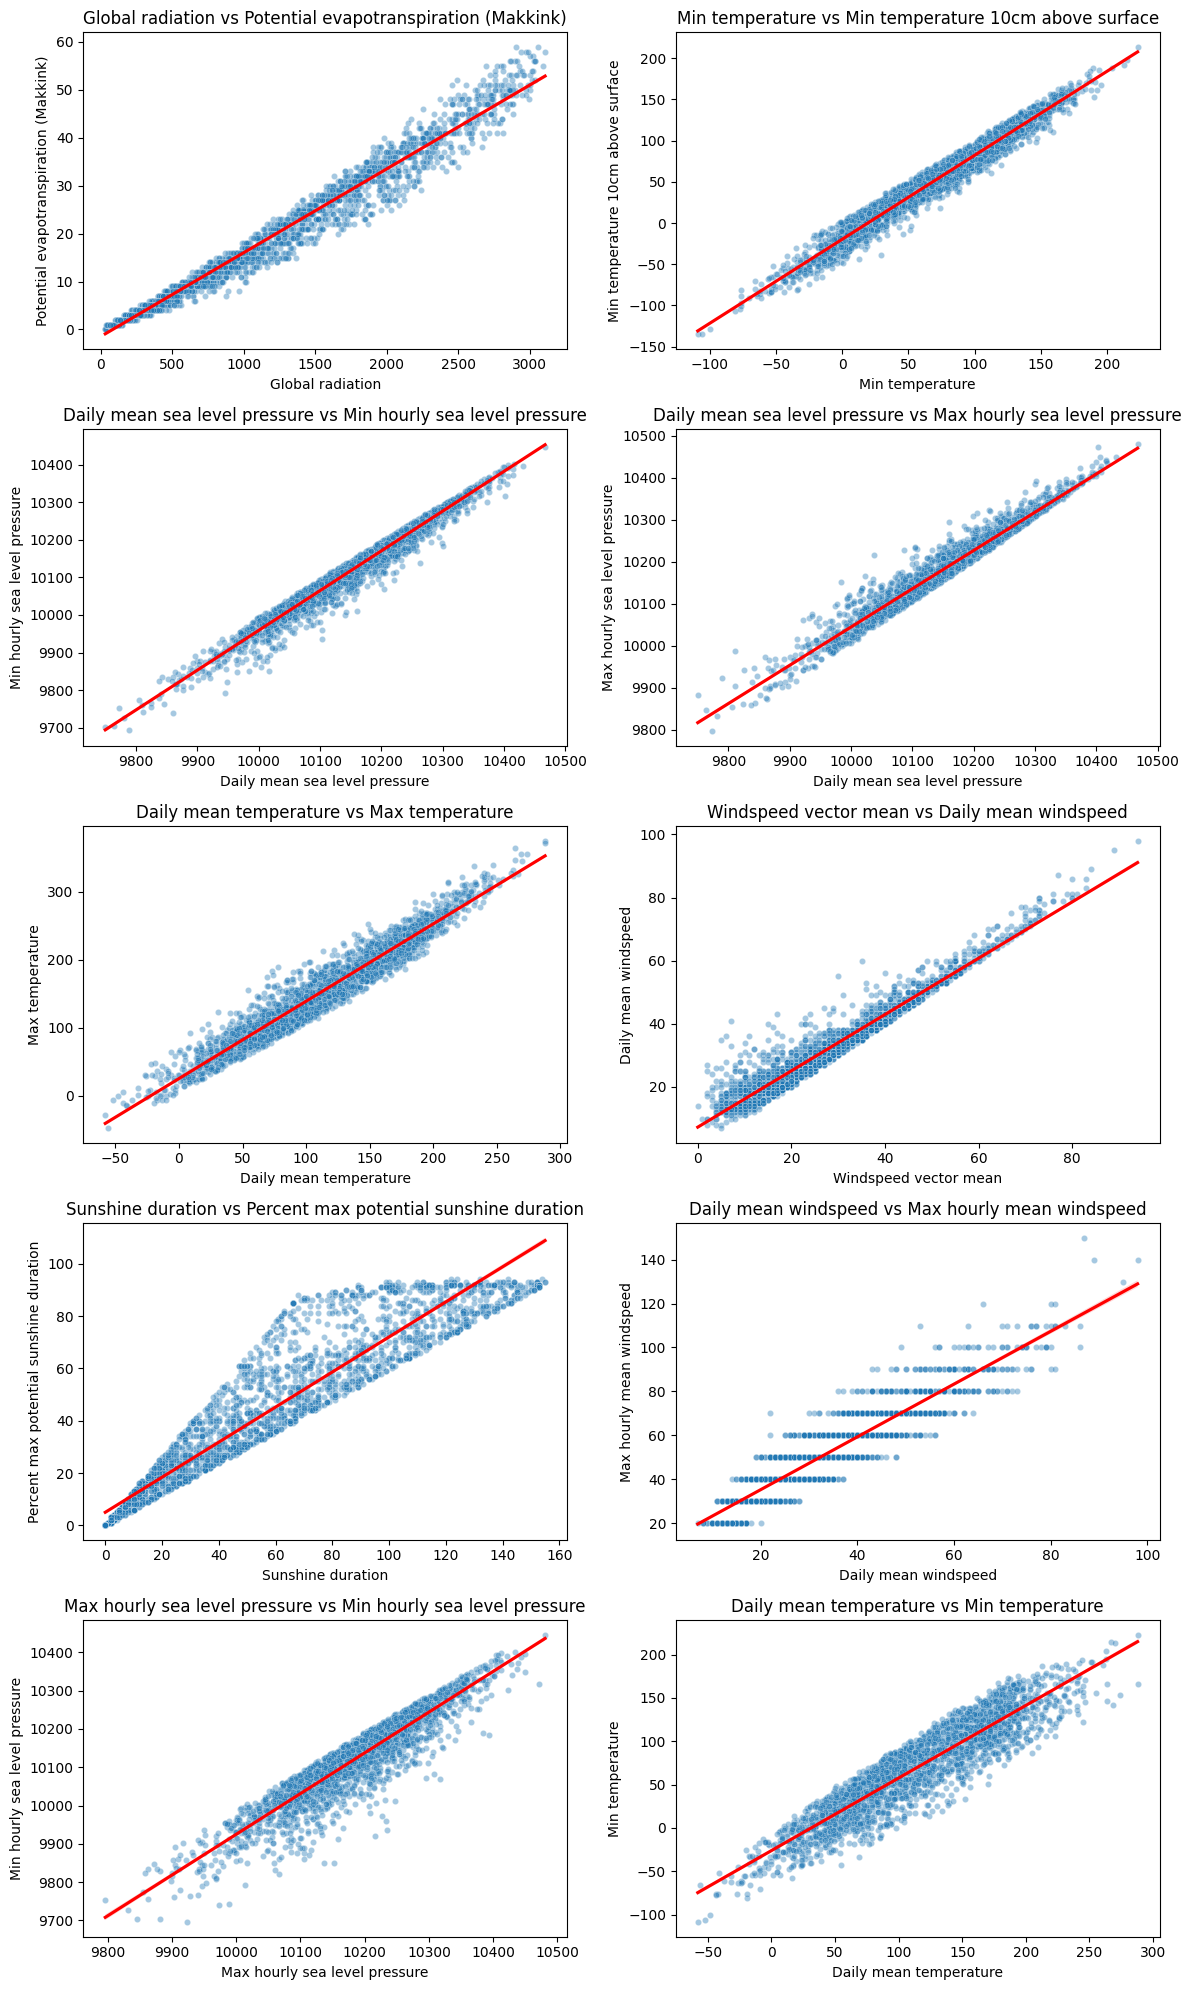

In [14]:
pairs = top_pairs.head(10).index.tolist()

n_pairs = len(pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=weather, x=x, y=y, alpha=0.4, s=20, ax=ax)
    sns.regplot(data=weather, x=x, y=y, scatter=False, color="red", ax=ax)
    ax.set_title(f"{x} vs {y}")

for ax in axes[n_pairs:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Preprocessing: Services

## Load in Data and quick Analysis

In [15]:
#read the csv file
serv19 = pd.read_csv("Train Services 2019-2025/services-2019.csv")

In [16]:
# Match Service:Date to weather timestamp style (YYYY-MM-DD 00:00:00)
serv19["Service:Date"] = pd.to_datetime(
    serv19["Service:Date"].astype(str).str[:10],
    format="%Y-%m-%d",
    errors="coerce"
 )

In [17]:
serv19.head(10)

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
0,738804,2019-01-01,Intercity,NS,1410,False,False,1,6220112,RTD,Rotterdam Centraal,NaN,NaN,NaN,2019-01-01T02:00:00+01:00,1.0,False,True,3,2
1,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220116,DT,Delft,2019-01-01T02:12:00+01:00,0.0,False,2019-01-01T02:12:00+01:00,0.0,False,False,1,1
2,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220120,GV,Den Haag HS,2019-01-01T02:20:00+01:00,1.0,False,2019-01-01T02:21:00+01:00,1.0,False,False,6,6
3,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220124,LEDN,Leiden Centraal,2019-01-01T02:35:00+01:00,0.0,False,2019-01-01T02:45:00+01:00,0.0,False,False,5b,5b
4,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220128,SHL,Schiphol Airport,2019-01-01T03:00:00+01:00,0.0,False,2019-01-01T03:02:00+01:00,0.0,False,False,3,3
5,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220134,ASD,Amsterdam Centraal,2019-01-01T03:16:00+01:00,1.0,False,2019-01-01T03:19:00+01:00,0.0,False,False,2b,2b
6,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220142,UT,Utrecht Centraal,2019-01-01T03:54:00+01:00,0.0,False,NaN,NaN,NaN,False,5,5
7,738805,2019-01-01,Intercity,NS,1409,False,False,2,6220118,UT,Utrecht Centraal,NaN,NaN,NaN,2019-01-01T02:17:00+01:00,0.0,False,False,15,15
8,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220122,ASB,Amsterdam Bijlmer ArenA,2019-01-01T02:34:00+01:00,0.0,False,2019-01-01T02:34:00+01:00,0.0,False,False,6,6
9,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220125,ASD,Amsterdam Centraal,2019-01-01T02:44:00+01:00,1.0,False,2019-01-01T02:46:00+01:00,2.0,False,False,2a,2a


In [18]:
serv19.info()

<class 'pandas.DataFrame'>
RangeIndex: 20773804 entries, 0 to 20773803
Data columns (total 20 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Service:RDT-ID                int64         
 1   Service:Date                  datetime64[us]
 2   Service:Type                  str           
 3   Service:Company               str           
 4   Service:Train number          int64         
 5   Service:Completely cancelled  bool          
 6   Service:Partly cancelled      bool          
 7   Service:Maximum delay         int64         
 8   Stop:RDT-ID                   int64         
 9   Stop:Station code             str           
 10  Stop:Station name             str           
 11  Stop:Arrival time             str           
 12  Stop:Arrival delay            float64       
 13  Stop:Arrival cancelled        object        
 14  Stop:Departure time           str           
 15  Stop:Departure delay          float64    

In [19]:
# Stop-level cancellation targets
print(serv19["Stop:Departure cancelled"].value_counts(), "\n")
print(serv19["Stop:Departure cancelled"].value_counts(normalize=True) * 100, "\n")

print(serv19["Stop:Arrival cancelled"].value_counts(), "\n")
print(serv19["Stop:Arrival cancelled"].value_counts(normalize=True) * 100)

Stop:Departure cancelled
False    18116056
True       446781
Name: count, dtype: int64 

Stop:Departure cancelled
False    97.593143
True      2.406857
Name: proportion, dtype: float64 

Stop:Arrival cancelled
False    17838957
True       448307
Name: count, dtype: int64 

Stop:Arrival cancelled
False    97.548529
True      2.451471
Name: proportion, dtype: float64


## Preprocessing: Domestic

In [20]:
serv19["Service:Company"].value_counts()

Service:Company
NS            14518938
Arriva         3596998
Blauwnet        996023
R-net           754624
Valleilijn      297729
DB              162345
Eurobahn        127453
Breng           121645
NMBS            118621
ABRN             56438
GVB              16768
ns                2199
Abellio Ra        1316
Keolis             645
U-OV               606
Railexpert         567
Railpromo          467
Rail2U             197
Syntus             165
Qbuzz               37
.                   23
Name: count, dtype: int64

In [21]:
# Check if they appear together in the same contexts
# ns (lowercase) are busses, NS (uppercase) are trains. They should not appear together in the same 'Service:Type' category.
print("\n" + "="*30)
print("Check if 'NS' and 'ns' appear with same 'Service:Type':")
print(pd.crosstab(serv19["Service:Company"], serv19["Service:Type"]))


Check if 'NS' and 'ns' appear with same 'Service:Type':
Service:Type     Alpen Express  Belbus  Bus  Dinner Train  Eurostar  \
Service:Company                                                       
.                            0       0    0             0         0   
ABRN                         0       0    0             0         0   
Abellio Ra                   0       0    0             0         0   
Arriva                       0       0    0             0         0   
Blauwnet                     0       0    0             0         0   
Breng                        0       0    0             0         0   
DB                           0       0    0             0         0   
Eurobahn                     0       0    0             0         0   
GVB                          0       0    0             0         0   
Keolis                       0       0    0             0         0   
NMBS                         0       0    0             0         0   
NS                  

In [22]:
serv19["Service:Type"].value_counts()

Service:Type
Sprinter                9787865
Stoptrein               4946057
Intercity               4762159
Stopbus i.p.v. trein     329637
Sneltrein                308156
Intercity direct         216433
stoptrein                162345
Snelbus i.p.v. trein     109199
Thalys                    36667
Extra trein               32044
ICE International         26971
Metro                     16768
RE 19                     16380
Speciale Trein            11414
Eurostar                   5197
Int. Trein                 3242
Bus                        1983
Dinner Train                497
Belbus                      446
Alpen Express               206
Train Charter                83
Krokus Express               24
Stoomtrein                   24
InnovationXpress              4
Niet instappen                3
Name: count, dtype: int64

In [23]:
# Show rows with specific columns
speciale_trein_rows = serv19[(serv19["Service:Type"] == "Speciale Trein")]

speciale_trein_rows

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
58141,745123,2019-01-02,Speciale Trein,NS,28301,False,False,1,6276026,UT,Utrecht Centraal,NaN,NaN,NaN,2019-01-02T09:31:00+01:00,0.0,False,False,1,1
58142,745123,2019-01-02,Speciale Trein,NS,28301,False,False,0,6277704,UTM,Utrecht Maliebaan,2019-01-02T09:48:00+01:00,1.0,False,NaN,NaN,NaN,False,2,2
59582,745278,2019-01-02,Speciale Trein,NS,28302,False,False,0,6277441,UTM,Utrecht Maliebaan,NaN,NaN,NaN,2019-01-02T09:56:00+01:00,0.0,False,False,2,2
59583,745278,2019-01-02,Speciale Trein,NS,28302,False,False,0,6278581,UT,Utrecht Centraal,2019-01-02T10:15:00+01:00,0.0,False,NaN,NaN,NaN,False,1,1
61357,745467,2019-01-02,Speciale Trein,NS,28305,False,False,2,6279274,UT,Utrecht Centraal,NaN,NaN,NaN,2019-01-02T10:31:00+01:00,0.0,False,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20764812,3107071,2019-12-31,Speciale Trein,NS,28334,True,True,0,26984780,UT,Utrecht Centraal,2019-12-31T18:13:00+01:00,0.0,True,NaN,NaN,NaN,False,NaN,NaN
20766740,3107276,2019-12-31,Speciale Trein,NS,28337,True,True,0,26986707,UT,Utrecht Centraal,NaN,NaN,NaN,2019-12-31T18:31:00+01:00,0.0,True,False,NaN,NaN
20766741,3107276,2019-12-31,Speciale Trein,NS,28337,True,True,0,26986708,UTM,Utrecht Maliebaan,2019-12-31T18:48:00+01:00,0.0,True,NaN,NaN,NaN,False,NaN,NaN
20768949,3107518,2019-12-31,Speciale Trein,NS,28338,True,True,0,26988915,UTM,Utrecht Maliebaan,NaN,NaN,NaN,2019-12-31T19:11:00+01:00,0.0,True,False,NaN,NaN


In [24]:
# Stations located in the Netherlands
dutch_stations= [
    "Dordrecht",
    "Dordrecht Stadspolders",
    "Sliedrecht Baanhoek",
    "Sliedrecht",
    "Hardinxveld Blauwe Zoom",
    "Hardinxveld-Giessendam",
    "Boven-Hardinxveld",
    "Gorinchem",
    "Arkel",
    "Leerdam",
    "Beesd",
    "Geldermalsen",
    "Groningen",
    "Groningen Noord",
    "Sauwerd",
    "Bedum",
    "Stedum",
    "Loppersum",
    "Appingedam",
    "Delfzijl West",
    "Delfzijl",
    "Roosendaal",
    "Winterswijk",
    "Aalten",
    "Varsseveld",
    "Terborg",
    "Gaanderen",
    "Doetinchem",
    "Doetinchem De Huet",
    "Wehl",
    "Didam",
    "Zevenaar",
    "Duiven",
    "Westervoort",
    "Arnhem Velperpoort",
    "Arnhem Centraal",
    "Groningen Europapark",
    "Kropswolde",
    "Martenshoek",
    "Hoogezand-Sappemeer",
    "Sappemeer Oost",
    "Zuidbroek",
    "Scheemda",
    "Winschoten",
    "Bad Nieuweschans",
    "Heerlen",
    "Heerlen Woonboulevard",
    "Voerendaal",
    "Klimmen-Ransdaal",
    "Schin op Geul",
    "Valkenburg",
    "Houthem-St. Gerlach",
    "Meerssen",
    "Maastricht Noord",
    "Maastricht",
    "Maastricht Randwyck",
    "Venlo",
    "Blerick",
    "Venray",
    "Vierlingsbeek",
    "Boxmeer",
    "Cuijk",
    "Mook Molenhoek",
    "Nijmegen Heyendaal",
    "Nijmegen",
    "Goor",
    "Delden",
    "Hengelo Gezondheidspark",
    "Hengelo",
    "Hengelo Oost",
    "Oldenzaal",
    "Lochem",
    "Zutphen",
    "Bunde",
    "Beek-Elsloo",
    "Geleen-Lutterade",
    "Sittard",
    "Susteren",
    "Echt",
    "Roermond",
    "Amersfoort",
    "Hoevelaken",
    "Barneveld Noord",
    "Barneveld Centrum",
    "Barneveld Zuid",
    "Lunteren",
    "Ede Centrum",
    "Ede-Wageningen",
    "Landgraaf",
    "Eygelshoven",
    "Chevremont",
    "Kerkrade Centrum",
    "Leeuwarden",
    "Mantgum",
    "Sneek Noord",
    "Sneek",
    "Hoensbroek",
    "Nuth",
    "Schinnen",
    "Spaubeek",
    "Geleen Oost",
    "Winsum",
    "Baflo",
    "Warffum",
    "Usquert",
    "Uithuizen",
    "Uithuizermeeden",
    "Roodeschool",
    "Veendam",
    "Eijsden",
    "Tegelen",
    "Reuver",
    "Swalmen",
    "Emmen",
    "Emmen Zuid",
    "Nieuw Amsterdam",
    "Dalen",
    "Coevorden",
    "Gramsbergen",
    "Hardenberg",
    "Mariënberg",
    "Ommen",
    "Dalfsen",
    "Zwolle",
    "Deinum",
    "Dronryp",
    "Franeker",
    "Harlingen",
    "Harlingen Haven",
    "Winterswijk West",
    "Lichtenvoorde-Groenlo",
    "Ruurlo",
    "Vorden",
    "Voorst-Empe",
    "Klarenbeek",
    "Apeldoorn De Maten",
    "Apeldoorn",
    "Zuidhorn",
    "Grijpskerk",
    "Buitenpost",
    "De Westereen",
    "Feanwâlden",
    "Hurdegaryp",
    "Leeuwarden Camminghaburen",
    "IJlst",
    "Workum",
    "Hindeloopen",
    "Koudum-Molkwerum",
    "Stavoren",
    "Vroomshoop",
    "Daarlerveen",
    "Vriezenveen",
    "Almelo",
    "Tiel",
    "Kesteren",
    "Opheusden",
    "Hemmen-Dodewaard",
    "Zetten-Andelst",
    "Elst",
    "Eemshaven",
    "Eindhoven",
    "Amsterdam Centraal",
    "Utrecht Centraal",
    "'s-Hertogenbosch",
    "Kruiningen-Yerseke",
    "Kapelle-Biezelinge",
    "Goes",
    "Arnemuiden",
    "Middelburg",
    "Vlissingen Souburg",
    "Vlissingen",
    "Zwijndrecht",
    "Breukelen",
    "Abcoude",
    "Amsterdam Holendrecht",
    "Amsterdam Bijlmer ArenA",
    "Duivendrecht",
    "Amsterdam Amstel",
    "Amsterdam Muiderpoort",
    "Bussum Zuid",
    "Hilversum Media Park",
    "Hilversum",
    "Baarn",
    "Amersfoort Schothorst",
    "Alkmaar",
    "Schagen",
    "Rotterdam Centraal",
    "Schiedam Centrum",
    "Delft",
    "Den Haag HS",
    "Den Haag Laan v NOI",
    "Leiden Centraal",
    "Heemstede-Aerdenhout",
    "Haarlem",
    "Amsterdam Sloterdijk",
    "Gouda",
    "Gouda Goverwelle",
    "Woerden",
    "Vleuten",
    "Utrecht Terwijde",
    "Utrecht Leidsche Rijn",
    "Bergen op Zoom",
    "Rilland-Bath",
    "Krabbendijke",
    "Assen",
    "Amersfoort Centraal",
    "Eygelshoven Markt",
]

In [25]:
# Get unique station names
unique_stations = serv19["Stop:Station name"].dropna().unique()

# Print all without truncation
print("All unique station names:")
for station in unique_stations:
    print(station)

All unique station names:
Rotterdam Centraal
Delft
Den Haag HS
Leiden Centraal
Schiphol Airport
Amsterdam Centraal
Utrecht Centraal
Amsterdam Bijlmer ArenA
Lelystad Centrum
Almere Oostvaarders
Almere Buiten
Almere Parkwijk
Almere Centrum
Almere Muziekwijk
Almere Poort
Weesp
Diemen Zuid
Duivendrecht
Amsterdam RAI
Amsterdam Zuid
Hoofddorp
Amersfoort
Baarn
Hilversum
Hilversum Media Park
Bussum Zuid
Naarden-Bussum
Diemen
Amsterdam Science Park
Amsterdam Muiderpoort
Alkmaar
Heiloo
Castricum
Uitgeest
Krommenie-Assendelft
Wormerveer
Zaandijk Zaanse Schans
Koog aan de Zaan
Zaandam
Amsterdam Sloterdijk
Hoorn
Purmerend Overwhere
Purmerend
Purmerend Weidevenne
Zaandam Kogerveld
Amsterdam Lelylaan
Utrecht Overvecht
Hollandsche Rading
Hilversum Sportpark
Rotterdam Blaak
Rotterdam Zuid
Rotterdam Lombardijen
Barendrecht
Zwijndrecht
Dordrecht
Schiedam Centrum
Delft Zuid
Rijswijk
Den Haag Moerwijk
Den Haag Centraal
Arnhem Centraal
Zevenaar
Nieuw Vennep
Sassenheim
De Vink
Voorschoten
Den Haag Mariahoeve

In [26]:
# Dropped since only 3 stations are in the neterlands
# Get unique station names for service type == stoptrein
stoptrein_rows = serv19[
    serv19["Service:Type"] == "stoptrein" #note lowercase s
]
unique_stations = stoptrein_rows["Stop:Station name"].dropna().unique()

# Print all without truncation
print("All unique station names for stoptrein:")
for station in unique_stations:
    print(station)

# only these stations in the netherland: "Enschede", "Enschede De Eschmarke", "Glanerbrug"

All unique station names for stoptrein:
Enschede
Enschede De Eschmarke
Glanerbrug
Gronau (Westf.)
Ochtrup
Metelen Land
Steinfurt-Burgsteinfurt
Steinfurt-Borghorst
Nordwalde
Altenberge
Münster-Häger
Münster (W) Zentrum Nord
Münster (Westf) Hbf
Dortmund Hbf
Dortmund Kirchderne
Dortmund Derne
Preussen
Lünen Hbf
Bork (Westf)
Selm-Beifang
Selm
Lüdinghausen
Dülmen
Lette (Kr Coesfeld)
Coesfeld (Westf)
Rosendahl-Holtwick
Legden
Ahaus
Epe (Westf)


In [27]:
# Get unique station names for service type == stoptrein
stoptrein_rows = serv19[
    serv19["Service:Type"] == "Stoptrein" #note uppercase S
]
unique_stations = stoptrein_rows["Stop:Station name"].dropna().unique()

# Print all without truncation
print("All unique station names for stoptrein:")
for station in unique_stations:
    print(station)

# only these stations in the netherland: "Enschede", "Enschede De Eschmarke", "Glanerbrug"

All unique station names for stoptrein:
Dordrecht
Dordrecht Stadspolders
Sliedrecht Baanhoek
Sliedrecht
Hardinxveld Blauwe Zoom
Hardinxveld-Giessendam
Boven-Hardinxveld
Gorinchem
Arkel
Leerdam
Beesd
Geldermalsen
Groningen
Groningen Noord
Sauwerd
Bedum
Stedum
Loppersum
Appingedam
Delfzijl West
Delfzijl
Roosendaal
Winterswijk
Aalten
Varsseveld
Terborg
Gaanderen
Doetinchem
Doetinchem De Huet
Wehl
Didam
Zevenaar
Duiven
Westervoort
Arnhem Velperpoort
Arnhem Centraal
Groningen Europapark
Kropswolde
Martenshoek
Hoogezand-Sappemeer
Sappemeer Oost
Zuidbroek
Scheemda
Winschoten
Bad Nieuweschans
Heerlen
Heerlen Woonboulevard
Voerendaal
Klimmen-Ransdaal
Schin op Geul
Valkenburg
Houthem-St. Gerlach
Meerssen
Maastricht Noord
Maastricht
Maastricht Randwyck
Venlo
Blerick
Venray
Vierlingsbeek
Boxmeer
Cuijk
Mook Molenhoek
Nijmegen Heyendaal
Nijmegen
Goor
Delden
Hengelo Gezondheidspark
Hengelo
Hengelo Oost
Oldenzaal
Lochem
Zutphen
Bunde
Beek-Elsloo
Geleen-Lutterade
Sittard
Susteren
Echt
Roermond
Amersfoo

In [28]:
# Get unique station names for service type == stoptrein
stoptrein_rows = serv19[
    serv19["Service:Type"] == "Sneltrein" 
]
unique_stations = stoptrein_rows["Stop:Station name"].dropna().unique()

# Print all without truncation
print("All unique station names for stoptrein:")
for station in unique_stations:
    print(station)

# only these stations in the netherland: "Enschede", "Enschede De Eschmarke", "Glanerbrug"

All unique station names for stoptrein:
Maastricht
Meerssen
Valkenburg
Heerlen
Landgraaf
Eygelshoven Markt
Emmen
Emmen Zuid
Nieuw Amsterdam
Coevorden
Hardenberg
Mariënberg
Ommen
Dalfsen
Zwolle
Groningen
Buitenpost
Leeuwarden
Dalen
Gramsbergen
Leeuwarden Camminghaburen
Heerlen Woonboulevard
Voerendaal
Klimmen-Ransdaal
Schin op Geul
Houthem-St. Gerlach
Maastricht Noord
Zuidhorn
Hurdegaryp
Aachen Hbf
Aachen West
Herzogenrath
Duisburg Hbf
Oberhausen Hbf
Oberhausen-Sterkrade
Wesel
Emmerich
Elten
Zevenaar
Arnhem Centraal
Düsseldorf Flughafen
Düsseldorf Hbf
Feanwâlden
Zutphen
Apeldoorn
Vorden
Ruurlo
Lichtenvoorde-Groenlo
Winterswijk West
Winterswijk
Grijpskerk


In [29]:
# Drop all rows where Service:Type is NOT in the list
serv19 = serv19[serv19["Service:Type"].isin(["Sprinter", "Stoptrein", "Intercity", "Intercity direct", "Extra trein", "Sneltrein"])]

# Keep only NS company
serv19 = serv19[serv19["Service:Company"] == "NS"]

# Keep only rows where Stop:Station name is in the Dutch stoptrein stations list
serv19 = serv19[serv19["Stop:Station name"].isin(dutch_stations)]

## Preprocessing Services: Analysis on Delay duration

In [30]:
serv19[["Service:Maximum delay"]].value_counts()

Service:Maximum delay
0                        5439154
1                         308625
2                         136697
3                          70839
4                          40843
                          ...   
206                            1
173                            1
137                            1
244                            1
224                            1
Name: count, Length: 166, dtype: int64

In [31]:
# Define bins (adjust depending on your data distribution)
bins = [0, 5, 10, 30, 60, 120, np.inf]
labels = ["0–5 min", "6–10 min", "11–30 min", "31–60 min", "61–120 min", "120+ min"]

# Categorize
delay_bins = pd.cut(
    serv19["Service:Maximum delay"].dropna(),
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Counts per category
delay_counts = delay_bins.value_counts().sort_index()

# Calculate percentages
delay_percentages = (delay_counts / delay_counts.sum()) * 100

# Create a DataFrame with both counts and percentages
delay_summary = pd.DataFrame({
    'Count': delay_counts,
    'Percentage': delay_percentages.round(4)
})

# Display
display(delay_summary)

,Count,Percentage
Service:Maximum delay,,
0–5 min,6022697,98.8717
6–10 min,43775,0.7186
11–30 min,22777,0.3739
31–60 min,1849,0.0304
61–120 min,266,0.0044
120+ min,64,0.0011


In [32]:
# Filter rows where delay is greater than 121 minutes, sorted descending
long_delays = serv19[(serv19["Service:Maximum delay"] >121)].sort_values(
    "Service:Maximum delay", 
    ascending=False
)

# Display the rows
display(long_delays)

#highest delay is 999 minutes, which is around 16.65 hour

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
523366,796047,2019-01-10,Sprinter,NS,6652,False,True,999,6741216,DDR,Dordrecht,NaN,NaN,NaN,2019-01-10T14:58:00+01:00,0.0,False,False,4b,4b
10748982,1970677,2019-07-13,Intercity,NS,3992,True,True,999,16967907,HRL,Heerlen,NaN,NaN,NaN,2019-07-13T23:49:00+02:00,999.0,True,False,5,5
11374712,2046720,2019-07-25,Intercity,NS,2423,False,True,999,17592886,LEDN,Leiden Centraal,NaN,NaN,NaN,2019-07-25T06:30:00+02:00,5.0,False,False,8b,8b
2808041,1053180,2019-02-20,Sprinter,NS,6371,True,True,888,9025799,HLM,Haarlem,NaN,NaN,NaN,2019-02-20T17:55:00+01:00,25.0,True,False,4,4
5441964,1355028,2019-04-09,Sprinter,NS,5824,True,True,888,11659955,ASD,Amsterdam Centraal,NaN,NaN,NaN,2019-04-09T09:30:00+02:00,888.0,True,False,14b,14b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14990151,2473144,2019-09-27,Intercity,NS,2984,False,True,127,21210131,MT,Maastricht,NaN,NaN,NaN,2019-09-27T22:01:00+02:00,0.0,False,False,3,3
17839758,2793648,2019-11-13,Sprinter,NS,6627,False,False,124,24059761,AH,Arnhem Centraal,NaN,NaN,NaN,2019-11-13T07:56:00+01:00,5.0,False,False,6a,6a
4087413,1199395,2019-03-15,Intercity,NS,858,False,True,124,10305361,MT,Maastricht,NaN,NaN,NaN,2019-03-15T15:31:00+01:00,0.0,False,False,1,1
10803356,1977400,2019-07-15,Intercity,NS,625,False,False,123,17021299,RTD,Rotterdam Centraal,NaN,NaN,NaN,2019-07-15T07:35:00+02:00,0.0,False,False,14,14


## Preprocessing Services: Missing Values

In [33]:
total_serv19 = serv19.isnull().sum().sort_values(ascending=False)
percent_serv19 = (serv19.isnull().sum()/serv19.isnull().count()).sort_values(ascending=False)
missing_data_serv19 = pd.concat([total_serv19, percent_serv19], axis=1, keys=['Total', 'Percent'])
missing_data_serv19

,Total,Percent
Stop:Arrival delay,909382,0.149289
Stop:Arrival cancelled,909382,0.149289
Stop:Arrival time,909382,0.149289
Stop:Departure time,906037,0.148740
Stop:Departure delay,906037,0.148740
Stop:Departure cancelled,906037,0.148740
Stop:Planned platform,74618,0.012250
Stop:Actual platform,74618,0.012250
Service:Company,0,0.000000
Service:Type,0,0.000000


In [42]:
# Rows where departure cancellation is missing
departure_null = serv19[serv19["Stop:Departure cancelled"].isna()].copy()

# Missingness flags
departure_null["departure_time_isna"] = departure_null["Stop:Departure time"].isna()
departure_null["departure_delay_isna"] = departure_null["Stop:Departure delay"].isna()

# Overview table
summary_departure_null = pd.crosstab(
    departure_null["departure_time_isna"],
    departure_null["departure_delay_isna"],
    margins=True
)
display(summary_departure_null)

# Explicit rule check: both must be NaN
rule_holds = (departure_null["departure_time_isna"] & departure_null["departure_delay_isna"]).all()
print("Rule holds:", rule_holds)

# Show counterexamples, if any
violations = departure_null[~(departure_null["departure_time_isna"] & departure_null["departure_delay_isna"])]
print("Violations:", len(violations))
if len(violations) > 0:
    display(violations.head(20))

departure_delay_isna,True,All
departure_time_isna,,
True,906037,906037
All,906037,906037


Rule holds: True
Violations: 0


In [41]:
# Rows where arrival cancellation is missing
arrival_null = serv19[serv19["Stop:Arrival cancelled"].isna()].copy()

# Missingness flags
arrival_null["arrival_time_isna"] = arrival_null["Stop:Arrival time"].isna()
arrival_null["arrival_delay_isna"] = arrival_null["Stop:Arrival delay"].isna()

# Overview table
summary_arrival_null = pd.crosstab(
    arrival_null["arrival_time_isna"],
    arrival_null["arrival_delay_isna"],
    margins=True
)
display(summary_arrival_null)

# Explicit rule check: both must be NaN
rule_holds = (arrival_null["arrival_time_isna"] & arrival_null["arrival_delay_isna"]).all()
print("Rule holds:", rule_holds)

# Show counterexamples, if any
violations = arrival_null[~(arrival_null["arrival_time_isna"] & arrival_null["arrival_delay_isna"])]
print("Violations:", len(violations))
if len(violations) > 0:
    display(violations.head(20))

arrival_delay_isna,True,All
arrival_time_isna,,
True,909382,909382
All,909382,909382


Rule holds: True
Violations: 0


In [40]:
# Check rows where planned platform is NaN or False
planned_col = serv19["Stop:Planned platform"]
actual_col = serv19["Stop:Actual platform"]

planned_is_false = planned_col.eq(False) | planned_col.astype(str).str.strip().str.lower().eq("false")
planned_is_na_or_false = planned_col.isna() | planned_is_false

planned_platform_null = serv19.loc[planned_is_na_or_false, ["Stop:Planned platform", "Stop:Actual platform"]].copy()

# Create boolean flags for missingness (without overwriting original columns)
planned_platform_null["planned_is_na"] = planned_platform_null["Stop:Planned platform"].isna()
planned_platform_null["actual_is_na"] = planned_platform_null["Stop:Actual platform"].isna()

# Summary: among rows where planned is NaN or False, is actual also NaN?
summary_planned_platform_null = pd.crosstab(
    planned_platform_null["planned_is_na"],
    planned_platform_null["actual_is_na"],
    margins=True
)

display(summary_planned_platform_null)

# Rows that do NOT satisfy "both planned and actual are NaN"
violations = planned_platform_null[
    ~(planned_platform_null["planned_is_na"] & planned_platform_null["actual_is_na"])
]

print(f"Rows checked (planned NaN or False): {len(planned_platform_null)}")
print(f"Rows where both planned and actual are NaN: {len(planned_platform_null) - len(violations)}")
print(f"Violations: {len(violations)}")

if len(violations) > 0:
    display(violations.head(20))

actual_is_na,True,All
planned_is_na,,
True,74618,74618
All,74618,74618


Rows checked (planned NaN or False): 74618
Rows where both planned and actual are NaN: 74618
Violations: 0


In [37]:
departure_null[departure_null.isnull().any(axis=1)]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,departure_time_isna,departure_delay_isna
6,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220142,UT,...,0.0,False,NaN,NaN,NaN,False,5,5,True,True
14,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220143,RTD,...,0.0,False,NaN,NaN,NaN,False,8,8,True,True
21,738806,2019-01-01,Intercity,NS,1414,False,False,0,6220161,UT,...,0.0,False,NaN,NaN,NaN,False,5,5,True,True
28,738807,2019-01-01,Intercity,NS,1413,False,False,0,6220162,RTD,...,2.0,False,NaN,NaN,NaN,False,3,3,True,True
35,738808,2019-01-01,Intercity,NS,1418,False,False,0,6220253,UT,...,0.0,False,NaN,NaN,NaN,False,5,5,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20773633,3126656,2019-12-31,Intercity,NS,303632,True,True,0,27175948,ZL,...,0.0,True,NaN,NaN,NaN,False,NaN,NaN,True,True
20773647,3126657,2019-12-31,Intercity,NS,303634,True,True,0,27175962,ZL,...,0.0,True,NaN,NaN,NaN,False,NaN,NaN,True,True
20773724,3127136,2019-12-31,Intercity,NS,303935,False,True,0,27180717,HRL,...,1.0,False,NaN,NaN,NaN,False,5,5,True,True
20773761,3127870,2019-12-31,Intercity,NS,300547,False,True,0,27188008,GN,...,0.0,False,NaN,NaN,NaN,False,2b,2b,True,True


In [38]:
serv19[(serv19["Stop:Arrival cancelled"]==False)&(serv19["Stop:Departure cancelled"].isna())]

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform
6,738804,2019-01-01,Intercity,NS,1410,False,False,0,6220142,UT,Utrecht Centraal,2019-01-01T03:54:00+01:00,0.0,False,NaN,NaN,NaN,False,5,5
14,738805,2019-01-01,Intercity,NS,1409,False,False,0,6220143,RTD,Rotterdam Centraal,2019-01-01T03:57:00+01:00,0.0,False,NaN,NaN,NaN,False,8,8
21,738806,2019-01-01,Intercity,NS,1414,False,False,0,6220161,UT,Utrecht Centraal,2019-01-01T04:54:00+01:00,0.0,False,NaN,NaN,NaN,False,5,5
28,738807,2019-01-01,Intercity,NS,1413,False,False,0,6220162,RTD,Rotterdam Centraal,2019-01-01T04:57:00+01:00,2.0,False,NaN,NaN,NaN,False,3,3
35,738808,2019-01-01,Intercity,NS,1418,False,False,0,6220253,UT,Utrecht Centraal,2019-01-01T05:54:00+01:00,0.0,False,NaN,NaN,NaN,False,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20773571,3126502,2019-12-31,Intercity,NS,303627,False,True,0,27174385,RSD,Roosendaal,2019-12-31T10:03:00+01:00,0.0,False,NaN,NaN,NaN,False,3a,3a
20773585,3126520,2019-12-31,Intercity,NS,303630,False,True,0,27174546,ZL,Zwolle,2019-12-31T11:41:00+01:00,0.0,False,NaN,NaN,NaN,False,10,10
20773724,3127136,2019-12-31,Intercity,NS,303935,False,True,0,27180717,HRL,Heerlen,2019-12-31T12:41:00+01:00,1.0,False,NaN,NaN,NaN,False,5,5
20773761,3127870,2019-12-31,Intercity,NS,300547,False,True,0,27188008,GN,Groningen,2019-12-31T15:42:00+01:00,0.0,False,NaN,NaN,NaN,False,2b,2b


In [ ]:
# Test the 3 NaN scenarios for arrival/departure features

# 1) Robustly locate partial-cancelled column
partial_candidates = [
    "Service:Partly cancelled"
]
partial_col = next((c for c in partial_candidates if c in serv19.columns), None)

if partial_col is None:
    raise KeyError(
        "Could not find partial-cancelled column. "
        f"Checked: {partial_candidates}"
    )

# 2) Normalize partial-cancelled values to boolean (True/False/NaN)
partial_raw = serv19[partial_col]
partial_bool = partial_raw.map({True: True, False: False})
partial_bool = partial_bool.where(partial_bool.notna(), np.nan)
partial_bool = partial_bool.where(
    partial_bool.notna(),
    partial_raw.astype(str).str.strip().str.lower().map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
    })
)

# 3) Feature-missing flags
arr_time_na = serv19["Stop:Arrival time"].isna()
arr_delay_na = serv19["Stop:Arrival delay"].isna()
dep_time_na = serv19["Stop:Departure time"].isna()
dep_delay_na = serv19["Stop:Departure delay"].isna()

arrival_any_na = arr_time_na | arr_delay_na
arrival_all_na = arr_time_na & arr_delay_na
departure_any_na = dep_time_na | dep_delay_na
departure_all_na = dep_time_na & dep_delay_na

# 4) Scenarios as stated
# A: partial cancelled = False, Arrival features are NaN, Departure features are not NaN
scenario_A = (partial_bool == False) & arrival_all_na & (~departure_any_na)

# B: partial cancelled = False, Arrival features are not NaN, Departure features are NaN
scenario_B = (partial_bool == False) & (~arrival_any_na) & departure_all_na

# C: partial cancelled = True, arrival and/or departure has NaN
scenario_C = (partial_bool == True) & (arrival_any_na | departure_any_na)

# 5) Total missing counts as denominators
total_arrival_missing = arrival_all_na.sum()       # rows with all arrival features missing
total_departure_missing = departure_all_na.sum()   # rows with all departure features missing
total_any_missing = (arrival_any_na | departure_any_na).sum()  # rows with any arrival/departure NaN

# 6) Summary counts
scenario_summary = pd.DataFrame({
    "count": [scenario_A.sum(), scenario_B.sum(), scenario_C.sum()],
    "percent_of_missing": [
        scenario_A.sum() / total_arrival_missing * 100,
        scenario_B.sum() / total_departure_missing * 100,
        scenario_C.sum() / total_any_missing * 100,
    ],
    "denominator": [total_arrival_missing, total_departure_missing, total_any_missing],
}, index=["A_start_station", "B_end_station", "C_partial_cancel_with_missing"])

display(scenario_summary)

# 7) Optional overlap check (should usually be 0)
overlap_count = ((scenario_A.astype(int) + scenario_B.astype(int) + scenario_C.astype(int)) > 1).sum()
print("Overlapping rows across A/B/C:", overlap_count)

# 8) Show sample rows for manual validation
cols_to_show = [
    partial_col,
    "Stop:Arrival time", "Stop:Arrival delay",
    "Stop:Departure time", "Stop:Departure delay",
    "Stop:Station name", "Service:Train number", "Service:Date"
]


,count,percent_of_missing,denominator
A_start_station,865461,95.170236,909382
B_end_station,861607,95.096227,906037
C_partial_cancel_with_missing,88351,4.866700,1815419


Overlapping rows across A/B/C: 0
